# Évaluation des prédictions — Vente

Ce notebook charge le fichier `data_after_pred.csv` (prix de vente), calcule des métriques d'évaluation globales et par ville (MAE, RMSE, R²), affiche des visualisations et sauvegarde les résultats dans un dossier `evaluation_results`.

Instructions : exécuter les cellules dans l'ordre. Modifier `data_path` dans la cellule de configuration si nécessaire.

In [6]:
# Imports et configuration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
print('Imports OK')

Imports OK


In [7]:
def load_and_clean(path):
    """Charge le CSV, convertit la surface et force les colonnes numériques.
    Retourne un DataFrame nettoyé.
    """
    df = pd.read_csv(path)

    # conversion surface (virgule -> point) et coercition sécurisée
    if 'surface (m²)' in df.columns:
        df['surface (m²)'] = df['surface (m²)'].astype(str).str.replace(',', '.', regex=False)
        df['surface (m²)'] = pd.to_numeric(df['surface (m²)'], errors='coerce')
    else:
        if 'surface' in df.columns:
            df['surface (m²)'] = df['surface'].astype(str).str.replace(',', '.', regex=False)
            df['surface (m²)'] = pd.to_numeric(df['surface (m²)'], errors='coerce')
        else:
            raise ValueError('No surface column found')

    # coercition sécurisée pour colonnes numériques utiles (virgules possibles)
    for col in ['prix (€)', 'prix_predicté', 'étage', 'pièces', 'chambres']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

    # drop lignes incomplètes essentielles
    df = df.dropna(subset=['prix (€)', 'prix_predicté', 'ville', 'surface (m²)']).copy()

    # normaliser villes
    df['ville'] = df['ville'].astype(str).str.strip().str.lower()

    # Filtrage d'outliers raisonnables pour éviter de casser les visualisations
    max_price = 1e8  # 100 million euros
    max_surface = 5000  # m²
    max_floor = 200
    before = len(df)
    df = df[(df['prix (€)'].abs() <= max_price) & (df['prix_predicté'].abs() <= max_price) & (df['surface (m²)'].abs() <= max_surface)]
    if 'étage' in df.columns:
        df = df[df['étage'].abs() <= max_floor]
    after = len(df)
    print(f'Removed {before - after} rows by outlier thresholds')

    return df

In [8]:
def compute_global_metrics(df):
    y_true = df['prix (€)']
    y_pred = df['prix_predicté']
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'N': len(df)}

def compute_city_metrics(df):
    rows = []
    for city, g in df.groupby('ville'):
        y_t = g['prix (€)']
        y_p = g['prix_predicté']
        rows.append({
            'ville': city,
            'count': len(g),
            'MAE': mean_absolute_error(y_t, y_p),
            'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
            'R2': r2_score(y_t, y_p)
        })
    return pd.DataFrame(rows).sort_values('MAE')

In [9]:
def plot_and_save(df, city_metrics_df, outdir, min_count=5):
    os.makedirs(outdir, exist_ok=True)
    y_true = df['prix (€)']
    y_pred = df['prix_predicté']

    # Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mmin, mmax = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mmin, mmax], [mmin, mmax], 'r--', lw=1.5)
    plt.xlabel('Prix réel (€)')
    plt.ylabel('Prix prédit (€)')
    plt.title('Prix réel vs Prix prédit — Vente (Global)')
    plt.tight_layout()
    plt.show()

    # Residuals
    residuals = y_pred - y_true
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5, color='green')
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Prix prédit (€)')
    plt.ylabel('Résidu (prédit - réel) (€)')
    plt.title('Résidus — Vente (Global)')
    plt.tight_layout()
    plt.show()

    # MAE par ville (filtre)
    subset = city_metrics_df[city_metrics_df['count'] >= min_count].copy()
    if not subset.empty:
        plt.figure(figsize=(12, 6))
        sns.barplot(x='ville', y='MAE', data=subset.sort_values('MAE'))
        plt.xticks(rotation=45, ha='right')
        plt.title(f'MAE par ville (≥ {min_count} exemples)')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 6))
        sns.barplot(x='ville', y='R2', data=subset.sort_values('R2', ascending=False))
        plt.xticks(rotation=45, ha='right')
        plt.title(f'R² par ville (≥ {min_count} exemples)')
        plt.tight_layout()
        plt.show()

    # Sauvegarde des CSVs
    os.makedirs(outdir, exist_ok=True)
    city_metrics_df.to_csv(os.path.join(outdir, 'vente_city_metrics.csv'), index=False)
    gm = compute_global_metrics(df)
    pd.DataFrame([gm]).to_csv(os.path.join(outdir, 'vente_global_metrics.csv'), index=False)

    return outdir

Loading: data_after_pred.csv
Removed 1 rows by outlier thresholds
Rows after cleaning: 1593

Global metrics (Vente):
  N = 1593
  MAE = €158,810.94
  RMSE = €248,004.72
  R2 = 0.1543


,ville,count,MAE,RMSE,R2
23,limoges,32,48435.703092,59864.807631,0.260292
30,nanterre,32,55142.276910,69676.873912,0.769577
17,creteil,32,65317.120363,94789.720034,-0.176345
6,argenteuil,28,67011.754035,101332.434855,-0.050698
9,besançon,31,68143.032830,83471.976581,-0.476747
16,colombes,32,71470.336839,117725.015074,0.625642
29,nancy,32,90173.515577,101094.094601,-0.573240
37,reims,32,90258.925848,112877.752059,0.706375
28,mulhouse,32,91717.446008,137708.004903,-0.280950
36,perpignan,32,93772.192437,122979.731225,0.284834


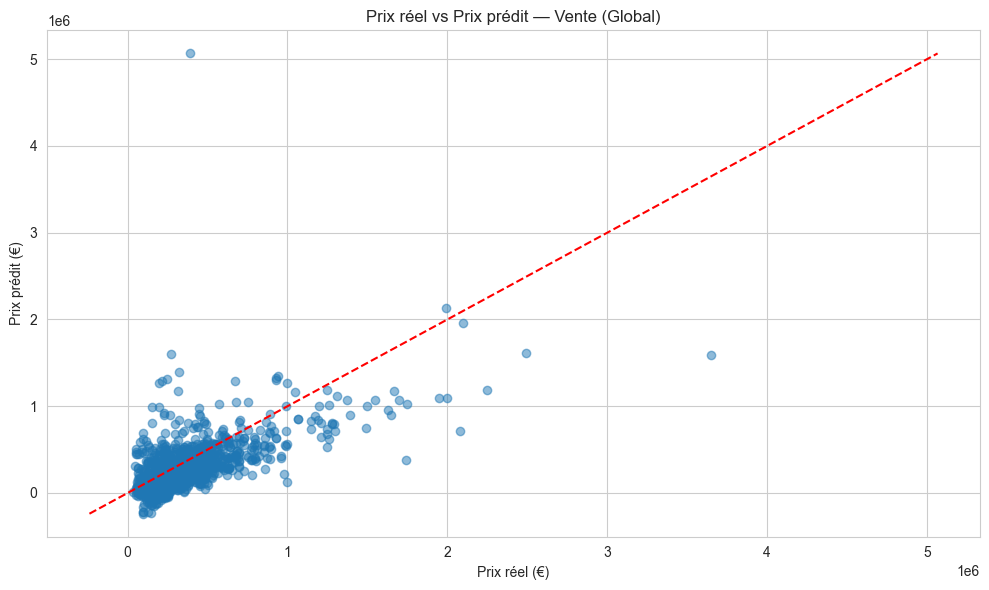

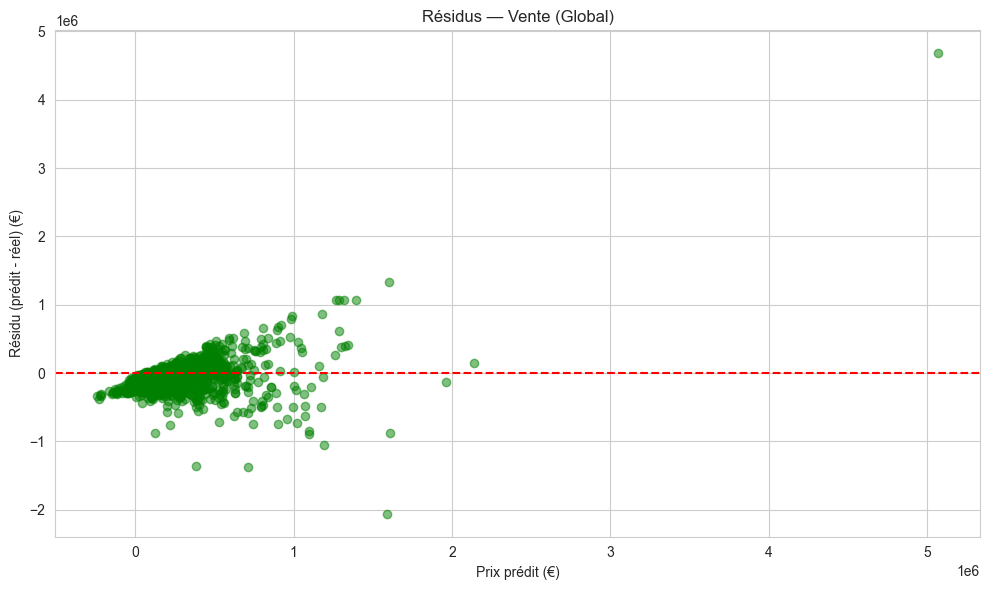

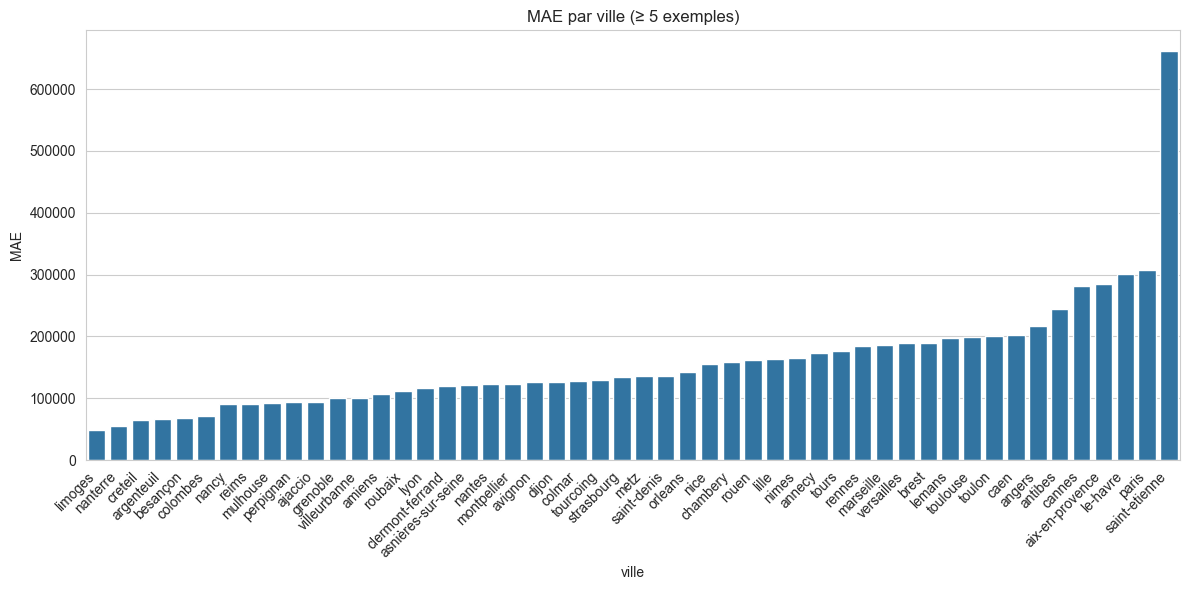

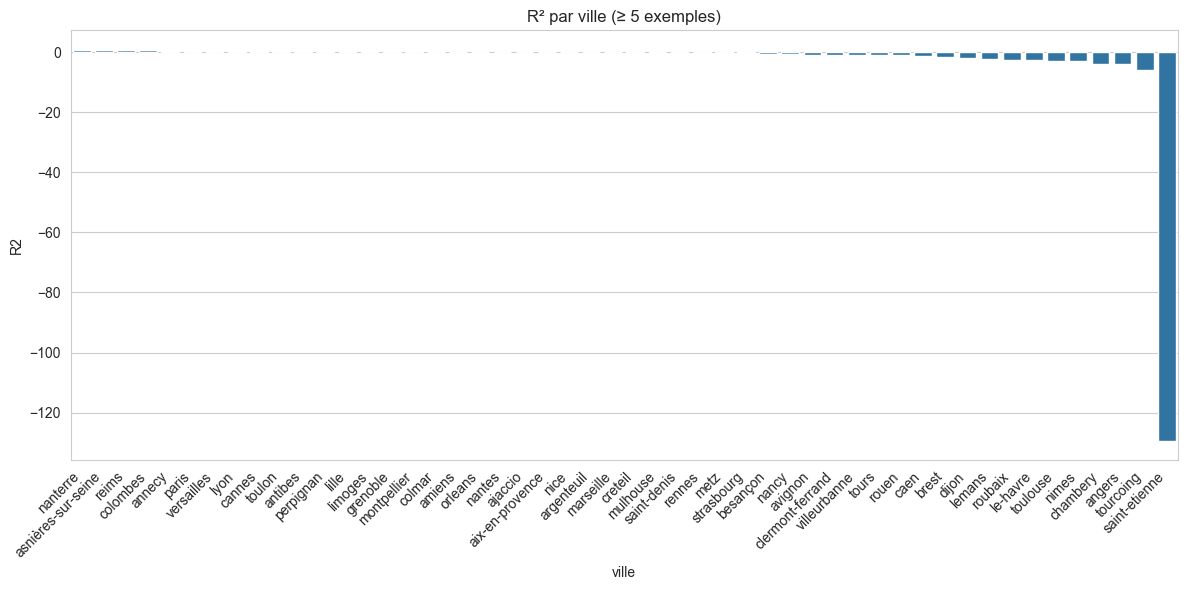

Outputs saved to: c:\Users\gaith\Desktop\yonnov'ia\prediction_test\vente\evaluation_results


In [10]:
# --- Configuration (modifier si besoin) ---
data_path = 'data_after_pred.csv'
outdir = 'evaluation_results'
min_count = 5

print(f'Loading: {data_path}')
df = load_and_clean(data_path)
print(f'Rows after cleaning: {len(df)}')

gm = compute_global_metrics(df)
print('\nGlobal metrics (Vente):')
print(f"  N = {gm['N']}")
print(f"  MAE = €{gm['MAE']:,.2f}")
print(f"  RMSE = €{gm['RMSE']:,.2f}")
print(f"  R2 = {gm['R2']:.4f}")

city_df = compute_city_metrics(df)
display(city_df.head(20))

saved = plot_and_save(df, city_df, outdir, min_count=min_count)
print(f'Outputs saved to: {os.path.abspath(saved)}')